## Land cover detection and moving windows
- Computing NDVI and NDWI with Landsat images 
- computing moving windows and study the correlations with LST depending on the size of the window.


### libraries and general paths

In [ ]:
import os
import rasterio
from rasterio.mask import mask
from rasterio.warp import transform_geom
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import convolve

In [ ]:
# user-defined paths
base_dir = '../../../datos-notebooks/3.global-data-cba/'
landsat_image = 'LC09_L2SP_229082_20240202_20240205_02_T1'

city_boundary = 'cba_boundary.gpkg'
# parameters for ndvi and ndwi classification
ndvi_dense_min = 0.29
ndvi_mid_min = 0.22
ndwi_true_min = 0.1

In [ ]:
# derived paths

# Rasters
green_path = os.path.join(base_dir, 'land-cover/landsat-bands', f"{landsat_image}_SR_B3.TIF")
red_path   = os.path.join(base_dir, 'land-cover/landsat-bands', f"{landsat_image}_SR_B4.TIF")
nir_path   = os.path.join(base_dir, 'land-cover/landsat-bands', f"{landsat_image}_SR_B5.TIF")
lst_path   = os.path.join(base_dir, 'LST', f"{landsat_image}_ST_B10.tif")
lst_cropped_path = os.path.join(base_dir, f'LST/LST_cropped_celsius{landsat_image}.tif') # values out of bound are 0
lst_clipped_path = os.path.join(base_dir, f'LST/LST_clipped_celsius{landsat_image}.tif') #values out of bound are nan

# Boundary
bound = os.path.join(base_dir, 'vectors/',city_boundary)

# Folders
output_folder_ndvi = os.path.join(base_dir, f'land-cover-{landsat_image}/ndvi')   
os.makedirs(output_folder_ndvi, exist_ok=True)
output_folder_ndwi = os.path.join(base_dir, f'land-cover-{landsat_image}/ndwi')   
os.makedirs(output_folder_ndwi, exist_ok=True)
output_folder_mw = os.path.join(base_dir, f'land-cover-{landsat_image}/moving-windows')
os.makedirs(output_folder_mw, exist_ok=True)  
output_folder_mw_ndwi = os.path.join(output_folder_mw, "ndwi/")
os.makedirs(output_folder_mw_ndwi, exist_ok=True)
output_folder_mw_ndvi = os.path.join(output_folder_mw, "ndvi/")
os.makedirs(output_folder_mw_ndvi, exist_ok=True)

# Indexes
ndvi_path = f"{output_folder_ndvi}/ndvi.tif"
ndwi_path = f"{output_folder_ndwi}/ndwi.tif"

# Classified indexes
ndvi_1_path = f"{output_folder_ndvi}/ndvi_1.tif"
ndvi_0p5_path = f"{output_folder_ndvi}/ndvi_0p5.tif"
ndwi_1_path = f"{output_folder_ndwi}/ndwi_1.tif"

In [ ]:
gdf = gpd.read_file(bound)

with rasterio.open(lst_path) as src:
    gdf= gdf.to_crs(src.crs)

### cropping and transforming the LST Image from Kelvin to Celsius

In [ ]:
# --- Load, crop and transform LST ---
with rasterio.open(lst_path) as src_lst:
    lst_crs = src_lst.crs
    gdf_lst = gdf.to_crs(lst_crs)
    lst_crop, lst_transform = mask(src_lst, gdf_lst.geometry, crop=True)
    lst_crop = lst_crop[0].astype(float) * 0.00341802 - 124.15  # transformation
    lst_crop[lst_crop < 0] = np.nan # --- Assign nodata to LST < 0 --- (nodata is -124.15 now)

# save the result
with rasterio.open(
    lst_cropped_path,
    "w",
    driver="GTiff",
    height=lst_crop.shape[0],
    width=lst_crop.shape[1],
    count=1,
    dtype=lst_crop.dtype,
    crs=lst_crs,
    transform=lst_transform,
) as dst:
    dst.write(lst_crop, 1)

In [ ]:
# Clip LST raster 

with rasterio.open(lst_cropped_path) as src:
    # Convert boundary to raster CRS
    boundary_crs = gdf.to_crs(src.crs)
    geoms = [boundary_crs.geometry.union_all().__geo_interface__]  # avoids deprecation warning

    # Clip raster to city boundary
    clipped_arr, clipped_transform = mask(
        src,
        geoms,
        crop=True,
        nodata=np.nan
    )

    # Convert to float and handle original nodata
    clipped_arr = clipped_arr.astype("float32")
    if src.nodata is not None:
        clipped_arr[clipped_arr == src.nodata] = np.nan

    # Remove extra dimensions
    clipped_arr = clipped_arr.squeeze()

    # Update metadata
    meta = src.meta.copy()
    meta.update({
        "height": clipped_arr.shape[0],
        "width": clipped_arr.shape[1],
        "transform": clipped_transform,
        "dtype": "float32",
        "nodata": np.nan
    })

# Save
with rasterio.open(lst_clipped_path, "w", **meta) as dst:
    dst.write(clipped_arr, 1)

In [ ]:
with rasterio.open(lst_clipped_path) as lst_crop:
    lst_crop = lst_crop.read(1)  
    
plt.figure(figsize=(8,6))
plt.imshow(lst_crop, cmap='hot')  
plt.colorbar(label='°C')
plt.title('LST Clipped')
plt.show()

###  Cropping images and computing NDVI, NDWI

In [ ]:
# Get LST extent + metadata for outputs
with rasterio.open(lst_cropped_path) as lst_src:
    lst_bounds = lst_src.bounds
    lst_geom = [{
        "type": "Polygon",
        "coordinates": [[
            (lst_bounds.left,  lst_bounds.bottom),
            (lst_bounds.left,  lst_bounds.top),
            (lst_bounds.right, lst_bounds.top),
            (lst_bounds.right, lst_bounds.bottom),
            (lst_bounds.left,  lst_bounds.bottom)
        ]]
    }]
    out_meta = lst_src.meta.copy()
    out_meta.update(dtype="float32", count=1, nodata=np.nan)

# get geometry for cropping
lst_geom = [{
    "type": "Polygon",
    "coordinates": [[
        (lst_bounds.left,  lst_bounds.bottom),
        (lst_bounds.left,  lst_bounds.top),
        (lst_bounds.right, lst_bounds.top),
        (lst_bounds.right, lst_bounds.bottom),
        (lst_bounds.left,  lst_bounds.bottom)
    ]]
}]

In [ ]:
# Crop 
def crop_band(path, geom):
    """Crop band to LST extent"""
    with rasterio.open(path) as src:
        data, _ = mask(src, geom, crop=True)
        return data[0].astype("float32")

green = crop_band(green_path, lst_geom)
red   = crop_band(red_path,   lst_geom)
nir   = crop_band(nir_path,   lst_geom)

np.seterr(divide="ignore", invalid="ignore")

# Indices
ndvi = (nir - red) / (nir + red)
ndwi = (green - nir) / (green + nir) 

# Save outputs
with rasterio.open(ndvi_path, "w", **out_meta) as dst:
    dst.write(ndvi.astype("float32"), 1)

with rasterio.open(ndwi_path, "w", **out_meta) as dst:
    dst.write(ndwi.astype("float32"), 1)


In [ ]:
with rasterio.open(ndvi_path) as src:
    ndvi = src.read(1)

with rasterio.open(ndwi_path) as src:
    ndwi = src.read(1)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# NDVI
im1 = axs[0].imshow(ndvi, cmap="Greens")
axs[0].set_title("NDVI")
axs[0].axis("off")
plt.colorbar(im1, ax=axs[0], fraction=0.046)

# NDWI
im2 = axs[1].imshow(ndwi, cmap="Blues")
axs[1].set_title("NDWI")
axs[1].axis("off")
plt.colorbar(im2, ax=axs[1], fraction=0.046)

plt.tight_layout()
plt.show()


#### classifying values

In [ ]:
with rasterio.open(ndvi_path) as src:
    ndvi = src.read(1)

with rasterio.open(ndwi_path) as src:
    ndwi = src.read(1)

ndvi_1 = np.where(ndvi > ndvi_dense_min, 1, 0).astype('float32')
ndvi_0p5 = np.where((ndvi > ndvi_mid_min) & (ndvi <= ndvi_dense_min),1,0).astype('float32')
ndwi_1 = np.where(ndwi > ndwi_true_min, 1, 0).astype('float32')

# Save outputs
with rasterio.open(lst_cropped_path) as lst_src:
    out_meta = lst_src.meta.copy()
    out_meta.update(dtype="float32", count=1, nodata=np.nan)

with rasterio.open(ndvi_1_path, "w", **out_meta) as dst:
    dst.write(ndvi_1.astype("float32"), 1)
    
with rasterio.open(ndvi_0p5_path, "w", **out_meta) as dst:
    dst.write(ndvi_0p5.astype("float32"), 1)

with rasterio.open(ndwi_1_path, "w", **out_meta) as dst:
    dst.write(ndwi_1.astype("float32"), 1)

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

white_to_green = LinearSegmentedColormap.from_list(
    "white_green", ["white", "#1a7a1a"]
)

white_to_yellow = LinearSegmentedColormap.from_list(
    "white_yellow", ["white", "#C79F00"]
)


white_to_blue = LinearSegmentedColormap.from_list(
    "white_blue", ["white", "#002E6D"]
)


ndvi_paths = {
    "Vegetación densa": ndvi_1_path,
    "Vegetación media": ndvi_0p5_path,
    "Agua": ndwi_1_path
}

fig, axes = plt.subplots(1, 3, figsize=(10, 6))
axes = axes.flatten()

for ax, (label, path) in zip(axes, ndvi_paths.items()):
    if label == "Vegetación media":
        cmap = white_to_yellow
        
    elif label == "Vegetación densa":
        cmap = white_to_green
    
    else:
        cmap = white_to_blue

    with rasterio.open(path) as src:
        out_image, out_transform = mask(src, gdf.geometry, crop=True)
        out_image = out_image[0]

        img = ax.imshow(out_image, cmap=cmap)
        ax.set_title(label)
        ax.axis("off")

    cbar = plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("% del pixel cubierto")

plt.tight_layout()
plt.show()


### moving windows 

In [ ]:
def distance_weighted_kernel(size):
    """Create a distance-weighted Gaussian kernel."""
    assert size % 2 == 1, "Window size must be odd"
    center = size // 2
    y, x = np.ogrid[:size, :size]
    distance = np.sqrt((x - center)**2 + (y - center)**2)
    sigma = size / 4  # controls smoothing strength
    weights = np.exp(-(distance**2) / (2 * sigma**2))
    weights /= weights.sum()  # normalize to sum=1
    return weights


def moving_window_weighted(array, kernel):
    """Apply distance-weighted convolution."""
    return convolve(array, kernel, mode='nearest')


#### NDVI

In [ ]:
ndvi_paths = {
    "class_1": ndvi_1_path,
    "class_0p5": ndvi_0p5_path,
}    

In [103]:
# Loop over classes
for class_name, path in ndvi_paths.items():
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        profile = src.profile

        # Loop over window sizes (ONLY odd sizes)
        for window_size in range(1, 101, 2):  
            kernel = distance_weighted_kernel(window_size)
            smoothed = moving_window_weighted(data, kernel)

            # Save raster
            out_profile = profile.copy()
            out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
            out_path = os.path.join(
                output_folder_mw_ndvi, 
                f"{class_name}_window{window_size}.tif"
            )

            with rasterio.open(out_path, "w", **out_profile) as dst:
                dst.write(smoothed.astype(np.float32), 1)


#### NDWI

In [104]:
with rasterio.open(ndwi_1_path) as src:
    data = src.read(1).astype(np.float32)
    profile = src.profile

    # Loop over window sizes (ONLY odd sizes)
    for window_size in range(1, 101, 2):  
        kernel = distance_weighted_kernel(window_size)
        smoothed = moving_window_weighted(data, kernel)

        # Save raster
        out_profile = profile.copy()
        out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
        out_path = os.path.join(
            output_folder_mw_ndwi, 
            f"class_1_window{window_size}.tif"
        )

        with rasterio.open(out_path, "w", **out_profile) as dst:
            dst.write(smoothed.astype(np.float32), 1)

### Correlations with LST

In [105]:
# general parameters
window_sizes = range(1, 101, 2)

# --- Load LST ---
with rasterio.open(lst_clipped_path) as lst:
    lst_crs = lst.crs
    lst_clip = lst.read(1)          
    lst_transform = lst.transform   

#### NDVI-LST

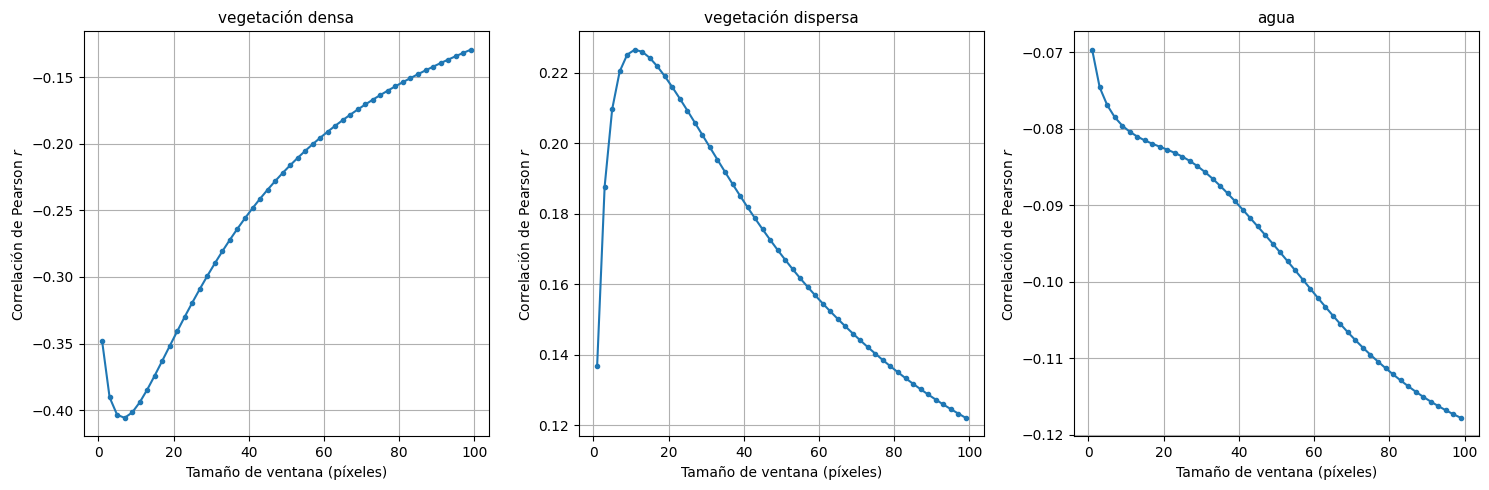

In [106]:
series = {
    "vegetación densa":   (output_folder_mw_ndvi, "class_1_window{w}.tif"),
    "vegetación dispersa": (output_folder_mw_ndvi, "class_0p5_window{w}.tif"),
    "agua":   (output_folder_mw_ndwi, "class_1_window{w}.tif"),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for ax, (label, (folder, pattern)) in zip(axes, series.items()):
    correlations = []
    for w in window_sizes:
        path = os.path.join(folder, pattern.format(w=w))
        with rasterio.open(path) as src:
            data_crop, _ = mask(src, gdf.geometry, crop=True)
            data_crop = data_crop[0].astype(float)

        valid = ~np.isnan(lst_clip)
        corr = np.corrcoef(data_crop[valid], lst_clip[valid])[0, 1]
        correlations.append(corr)

    ax.plot(window_sizes, correlations, marker='o', markersize=3)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Tamaño de ventana (píxeles)")
    ax.set_ylabel("Correlación de Pearson $r$")
    ax.grid(True)

plt.tight_layout()
plt.show()